<a href="https://colab.research.google.com/github/yomiannixs-jpg/AI-Optimization-app-using-LSTM_TensorFlow/blob/main/MScFE_600_GWP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving cleaned_oil_stock_data.csv to cleaned_oil_stock_data (2).csv
Original shape: (2562, 19)
  Unnamed: 0          ECH        ECH.1        ECH.2        ECH.3        ECH.4  \
0      Price         Open         High          Low        Close    Adj Close   
1     Ticker          ECH          ECH          ECH          ECH          ECH   
2       Date          NaN          NaN          NaN          NaN          NaN   
3  12/1/2009  52.00999832  52.43999863  51.68000031  52.34000015   34.4687233   
4  12/2/2009  52.56999969  52.56999969  51.75999832  51.79000092  34.10652542   

    ECH.5          EWZ        EWZ.1        EWZ.2        EWZ.3        EWZ.4  \
0  Volume         Open         High          Low        Close    Adj Close   
1     ECH          EWZ          EWZ          EWZ          EWZ          EWZ   
2     NaN          NaN          NaN          NaN          NaN          NaN   
3  244800  77.90000153  79.40000153  77.76999664  78.91999817  37.71046829   
4  103500  79.12999725  80.1

,count,mean,std,min,25%,50%,75%,max
Open,2360.0,2.049443e+02,5.737880e+01,108.7000,1.490050e+02,2.054100e+02,2.511625e+02,3.339100e+02
High,2360.0,2.058314e+02,5.752910e+01,112.9700,1.497175e+02,2.065200e+02,2.520550e+02,3.344400e+02
Low,2360.0,2.039424e+02,5.720110e+01,107.8000,1.480050e+02,2.045350e+02,2.499200e+02,3.326800e+02
Close,2360.0,2.049752e+02,5.736850e+01,110.2600,1.496100e+02,2.055050e+02,2.517325e+02,3.335000e+02
Adj_Close,2360.0,1.722447e+02,5.674710e+01,84.9619,1.184645e+02,1.703986e+02,2.180888e+02,3.029759e+02
Volume,2360.0,4.019471e+06,2.237757e+06,995500.0000,2.642225e+06,3.484450e+06,4.713925e+06,3.874850e+07


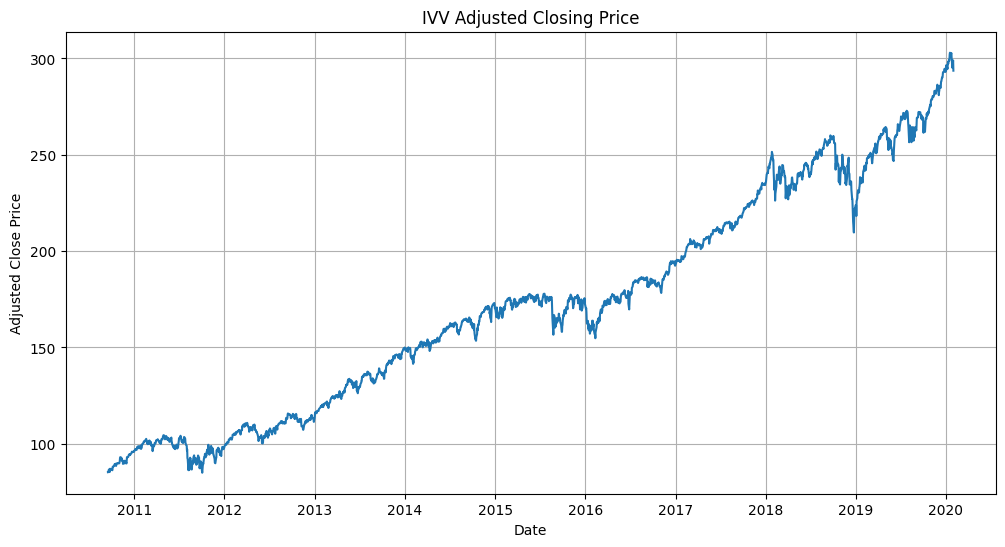


Feature matrix shape: (2360, 26)
Target vector shape: (2360,)

Top 15 features by absolute correlation with Gamma:


,Feature,Absolute_Correlation_with_Gamma
0,CCI_20,0.364173
1,BB_Percent,0.340798
2,RSI_14,0.279780
3,ROC_12,0.214607
4,MACD_Diff,0.184896
5,Volume,0.098898
6,MACD,0.070696
7,WILLR_14,0.047764
8,Low,0.030547
9,Open,0.028362


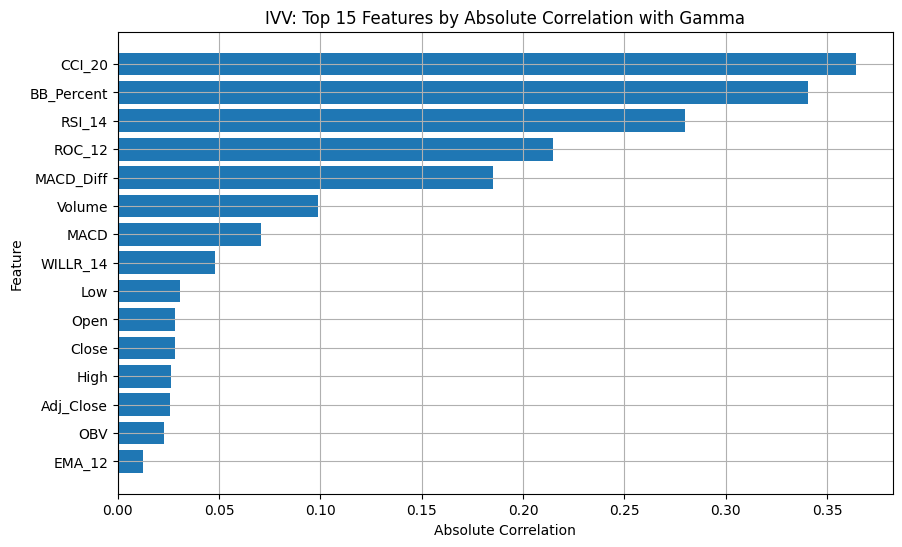

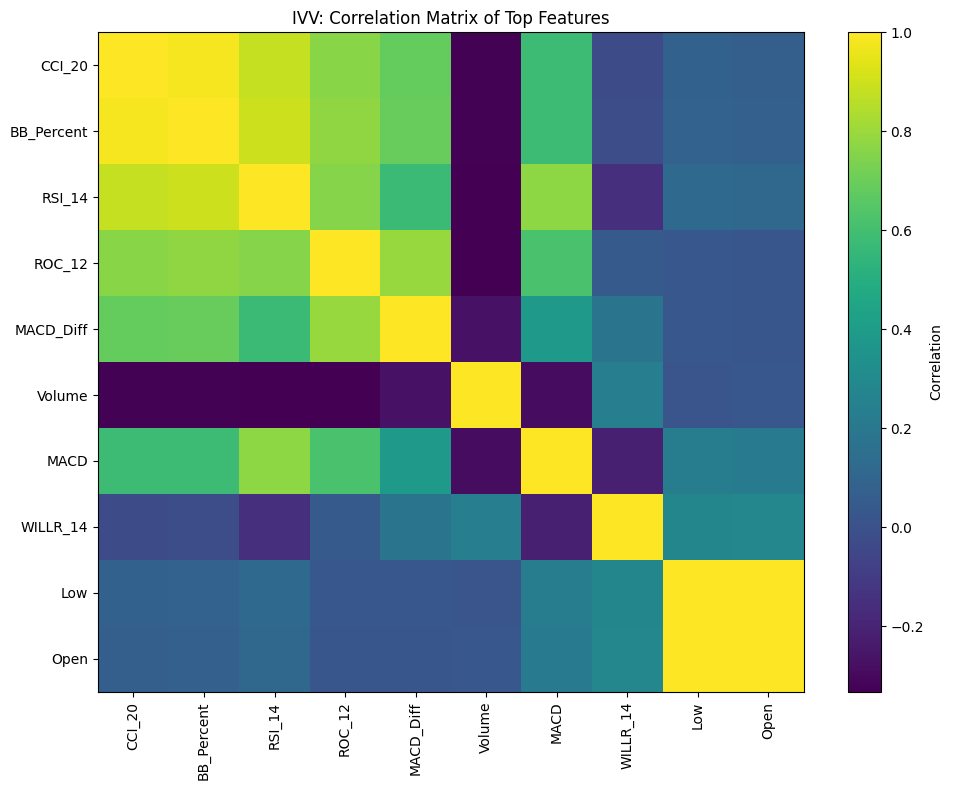


10-Fold Cross-Validation Results:


,Fold,Accuracy
0,1,0.7034
1,2,0.7161
2,3,0.7076
3,4,0.6992
4,5,0.7076
5,6,0.6907
6,7,0.7034
7,8,0.7161
8,9,0.7881
9,10,0.6949



Mean Accuracy: 0.7127
Standard Deviation: 0.0263


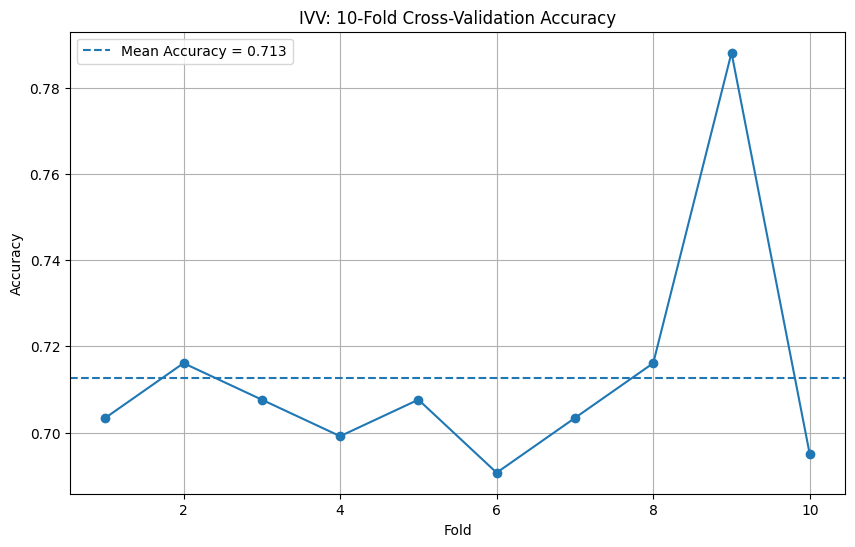


Top 15 Features by ANOVA F-Score:


,Feature,F_Score,P_Value
23,CCI_20,360.537120,0.000000
15,BB_Percent,309.853686,0.000000
6,RSI_14,200.251597,0.000000
7,ROC_12,113.843535,0.000000
10,MACD_Diff,83.465428,0.000000
5,Volume,23.291002,0.000001
8,MACD,11.844219,0.000588
25,WILLR_14,5.391953,0.020315
2,Low,2.202393,0.137930
0,Open,1.898364,0.168392


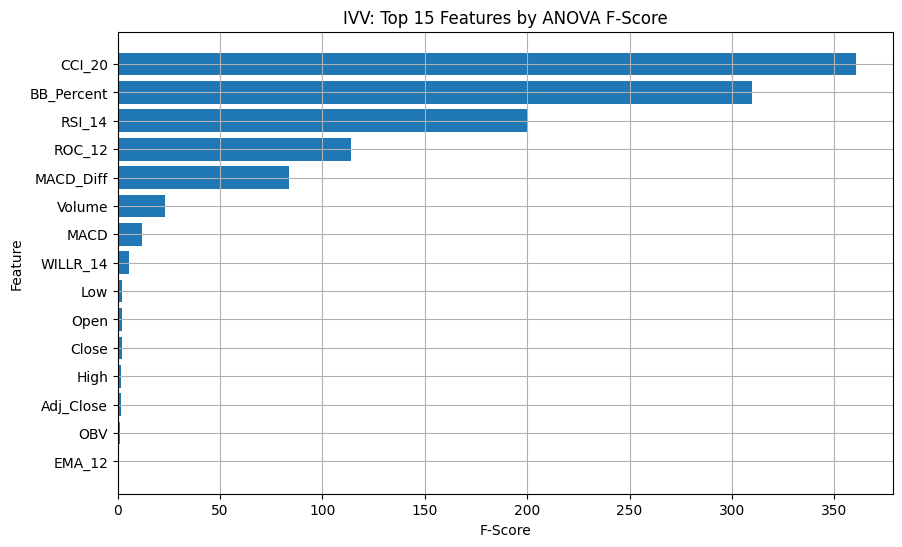


Saved files:
IVV_with_indicators.csv
IVV_descriptive_statistics.csv
IVV_correlation_ranking.csv
IVV_cross_validation_results.csv
IVV_anova_feature_scores.csv

Replication complete.


In [ ]:
# ============================================================
# MScFE 600 GWP1 - Part 1 Replication
# Uses your downloaded CSV directly
# Works with columns: ECH, ECH.1..., EWZ..., IVV...
# ============================================================

!pip install -q ta

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from ta.trend import SMAIndicator, EMAIndicator, MACD, CCIIndicator
from ta.momentum import RSIIndicator, ROCIndicator, WilliamsRIndicator
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline


# ============================================================
# 1. UPLOAD CSV
# ============================================================

uploaded = files.upload()
filename = list(uploaded.keys())[0]

raw = pd.read_csv(filename)

print("Original shape:", raw.shape)
print(raw.head())


# ============================================================
# 2. CLEAN YOUR SPECIAL CSV FORMAT
# ============================================================

# Your CSV has:
# row 0 = Price/Open/High/Low/Close/Adj Close/Volume labels
# row 1 = Ticker labels
# row 2 = Date row
# actual data starts at row 3

data_raw = raw.iloc[3:].copy()

# First column is Date
data_raw = data_raw.rename(columns={"Unnamed: 0": "Date"})
data_raw["Date"] = pd.to_datetime(data_raw["Date"], errors="coerce")
data_raw = data_raw.dropna(subset=["Date"])
data_raw = data_raw.set_index("Date")
data_raw = data_raw.sort_index()

# Rename columns manually according to your file structure
rename_cols = {
    "ECH": "ECH_Open",
    "ECH.1": "ECH_High",
    "ECH.2": "ECH_Low",
    "ECH.3": "ECH_Close",
    "ECH.4": "ECH_Adj_Close",
    "ECH.5": "ECH_Volume",

    "EWZ": "EWZ_Open",
    "EWZ.1": "EWZ_High",
    "EWZ.2": "EWZ_Low",
    "EWZ.3": "EWZ_Close",
    "EWZ.4": "EWZ_Adj_Close",
    "EWZ.5": "EWZ_Volume",

    "IVV": "IVV_Open",
    "IVV.1": "IVV_High",
    "IVV.2": "IVV_Low",
    "IVV.3": "IVV_Close",
    "IVV.4": "IVV_Adj_Close",
    "IVV.5": "IVV_Volume",
}

data_raw = data_raw.rename(columns=rename_cols)

# Convert all columns to numeric
for col in data_raw.columns:
    data_raw[col] = pd.to_numeric(data_raw[col], errors="coerce")

print("\nCleaned full dataset:")
print(data_raw.head())
print(data_raw.shape)


# ============================================================
# 3. SELECT ONE ETF FOR REPLICATION
# ============================================================

# Choose IVV, as recommended
ticker = "IVV"

df = pd.DataFrame({
    "Open": data_raw[f"{ticker}_Open"],
    "High": data_raw[f"{ticker}_High"],
    "Low": data_raw[f"{ticker}_Low"],
    "Close": data_raw[f"{ticker}_Close"],
    "Adj_Close": data_raw[f"{ticker}_Adj_Close"],
    "Volume": data_raw[f"{ticker}_Volume"],
})

df = df.dropna()

print("\nSelected ETF data:")
print(df.head())
print(df.shape)


# ============================================================
# 4. CREATE TECHNICAL INDICATORS
# ============================================================

data = df.copy()

close = data["Adj_Close"]
high = data["High"]
low = data["Low"]
volume = data["Volume"]

# Momentum indicators
data["RSI_14"] = RSIIndicator(close=close, window=14).rsi()
data["ROC_12"] = ROCIndicator(close=close, window=12).roc()

# MACD indicators
macd = MACD(close=close, window_slow=26, window_fast=12, window_sign=9)
data["MACD"] = macd.macd()
data["MACD_Signal"] = macd.macd_signal()
data["MACD_Diff"] = macd.macd_diff()

# Bollinger Bands
bb = BollingerBands(close=close, window=20, window_dev=2)
data["BB_High"] = bb.bollinger_hband()
data["BB_Mid"] = bb.bollinger_mavg()
data["BB_Low"] = bb.bollinger_lband()
data["BB_Width"] = bb.bollinger_wband()
data["BB_Percent"] = bb.bollinger_pband()

# Volatility
data["ATR_14"] = AverageTrueRange(
    high=high,
    low=low,
    close=close,
    window=14
).average_true_range()

# Moving averages
data["SMA_20"] = SMAIndicator(close=close, window=20).sma_indicator()
data["SMA_50"] = SMAIndicator(close=close, window=50).sma_indicator()
data["SMA_200"] = SMAIndicator(close=close, window=200).sma_indicator()

data["EMA_12"] = EMAIndicator(close=close, window=12).ema_indicator()
data["EMA_26"] = EMAIndicator(close=close, window=26).ema_indicator()
data["EMA_50"] = EMAIndicator(close=close, window=50).ema_indicator()

# CCI
data["CCI_20"] = CCIIndicator(
    high=high,
    low=low,
    close=close,
    window=20
).cci()

# OBV
data["OBV"] = OnBalanceVolumeIndicator(
    close=close,
    volume=volume
).on_balance_volume()

# Williams %R
data["WILLR_14"] = WilliamsRIndicator(
    high=high,
    low=low,
    close=close,
    lbp=14
).williams_r()


# ============================================================
# 5. CREATE TARGET VARIABLE GAMMA
# ============================================================

# Gamma = 1 if today's Open is higher than yesterday's Open
data["Gamma"] = (data["Open"] > data["Open"].shift(1)).astype(int)

# Drop missing values from indicators
data = data.dropna()

print("\nFinal dataset with indicators:")
print(data.head())
print("Shape:", data.shape)

print("\nGamma distribution:")
print(data["Gamma"].value_counts())


# ============================================================
# 6. DESCRIPTIVE STATISTICS
# ============================================================

desc_stats = data[
    ["Open", "High", "Low", "Close", "Adj_Close", "Volume"]
].describe().T

print("\nDescriptive Statistics:")
display(desc_stats.round(4))


# ============================================================
# 7. PRICE HISTORY GRAPH
# ============================================================

plt.figure(figsize=(12, 6))
plt.plot(data.index, data["Adj_Close"])
plt.title(f"{ticker} Adjusted Closing Price")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.grid(True)
plt.show()


# ============================================================
# 8. FEATURE MATRIX AND TARGET
# ============================================================

X = data.drop(columns=["Gamma"])
X = X.select_dtypes(include=[np.number])
y = data["Gamma"]

print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


# ============================================================
# 9. CORRELATION FEATURE RANKING
# ============================================================

corr_with_target = X.corrwith(y).abs().sort_values(ascending=False)

corr_table = corr_with_target.reset_index()
corr_table.columns = ["Feature", "Absolute_Correlation_with_Gamma"]

print("\nTop 15 features by absolute correlation with Gamma:")
display(corr_table.head(15))


# ============================================================
# 10. CORRELATION BAR CHART
# ============================================================

top_corr = corr_table.head(15).sort_values("Absolute_Correlation_with_Gamma")

plt.figure(figsize=(10, 6))
plt.barh(top_corr["Feature"], top_corr["Absolute_Correlation_with_Gamma"])
plt.title(f"{ticker}: Top 15 Features by Absolute Correlation with Gamma")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")
plt.grid(True)
plt.show()


# ============================================================
# 11. CORRELATION MATRIX OF TOP FEATURES
# ============================================================

top_features = corr_table["Feature"].head(10).tolist()
corr_matrix = data[top_features].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(top_features)), top_features, rotation=90)
plt.yticks(range(len(top_features)), top_features)
plt.title(f"{ticker}: Correlation Matrix of Top Features")
plt.tight_layout()
plt.show()


# ============================================================
# 12. 10-FOLD CROSS-VALIDATION WITH MLP
# ============================================================

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

model = Pipeline([
    ("scaler", MinMaxScaler()),
    ("selector", SelectKBest(score_func=f_classif, k=10)),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(20,),
        activation="logistic",
        solver="lbfgs",
        max_iter=5000,
        random_state=42
    ))
])

scores = cross_val_score(
    model,
    X,
    y,
    cv=kfold,
    scoring="accuracy"
)

cv_results = pd.DataFrame({
    "Fold": range(1, 11),
    "Accuracy": scores
})

print("\n10-Fold Cross-Validation Results:")
display(cv_results.round(4))

print("\nMean Accuracy:", round(scores.mean(), 4))
print("Standard Deviation:", round(scores.std(), 4))


# ============================================================
# 13. CROSS-VALIDATION GRAPH
# ============================================================

plt.figure(figsize=(10, 6))
plt.plot(cv_results["Fold"], cv_results["Accuracy"], marker="o")
plt.axhline(
    scores.mean(),
    linestyle="--",
    label=f"Mean Accuracy = {scores.mean():.3f}"
)
plt.title(f"{ticker}: 10-Fold Cross-Validation Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 14. ANOVA F-SCORE FEATURE SELECTION
# ============================================================

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X_scaled, y)

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "F_Score": selector.scores_,
    "P_Value": selector.pvalues_
})

feature_scores = feature_scores.sort_values("F_Score", ascending=False)

print("\nTop 15 Features by ANOVA F-Score:")
display(feature_scores.head(15).round(6))


# ============================================================
# 15. FEATURE IMPORTANCE GRAPH
# ============================================================

top_f_scores = feature_scores.head(15).sort_values("F_Score")

plt.figure(figsize=(10, 6))
plt.barh(top_f_scores["Feature"], top_f_scores["F_Score"])
plt.title(f"{ticker}: Top 15 Features by ANOVA F-Score")
plt.xlabel("F-Score")
plt.ylabel("Feature")
plt.grid(True)
plt.show()


# ============================================================
# 16. SAVE OUTPUT FILES
# ============================================================

data.to_csv(f"{ticker}_with_indicators.csv")
desc_stats.to_csv(f"{ticker}_descriptive_statistics.csv")
corr_table.to_csv(f"{ticker}_correlation_ranking.csv", index=False)
cv_results.to_csv(f"{ticker}_cross_validation_results.csv", index=False)
feature_scores.to_csv(f"{ticker}_anova_feature_scores.csv", index=False)

print("\nSaved files:")
print(f"{ticker}_with_indicators.csv")
print(f"{ticker}_descriptive_statistics.csv")
print(f"{ticker}_correlation_ranking.csv")
print(f"{ticker}_cross_validation_results.csv")
print(f"{ticker}_anova_feature_scores.csv")

print("\nReplication complete.")

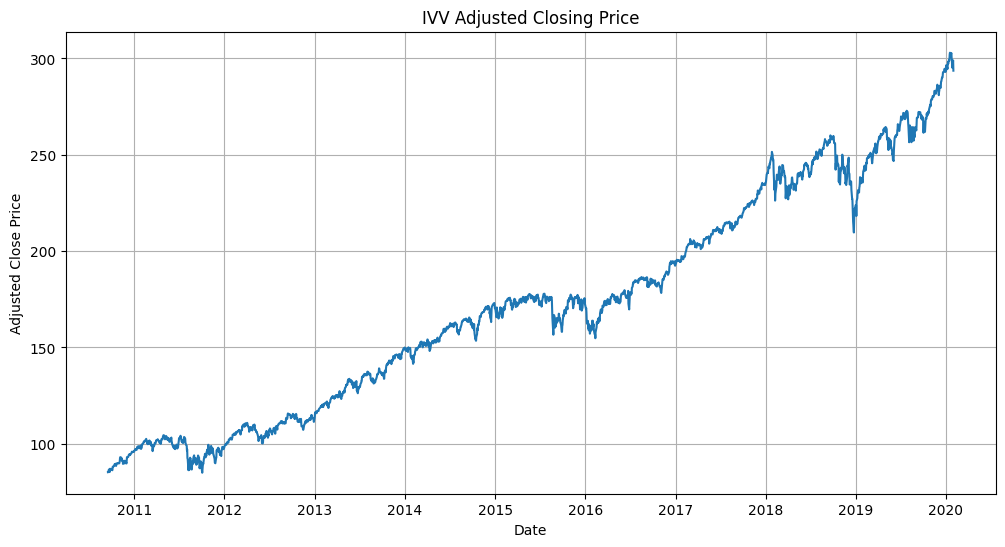

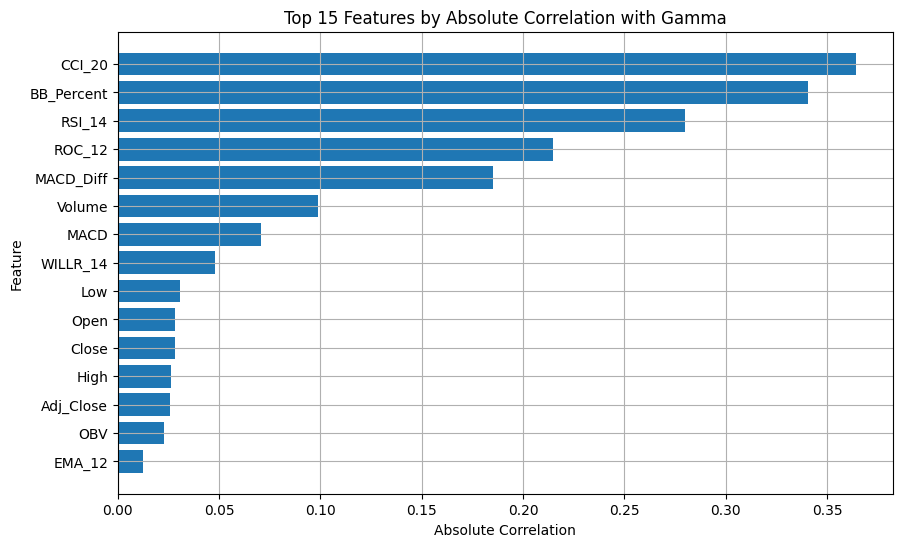

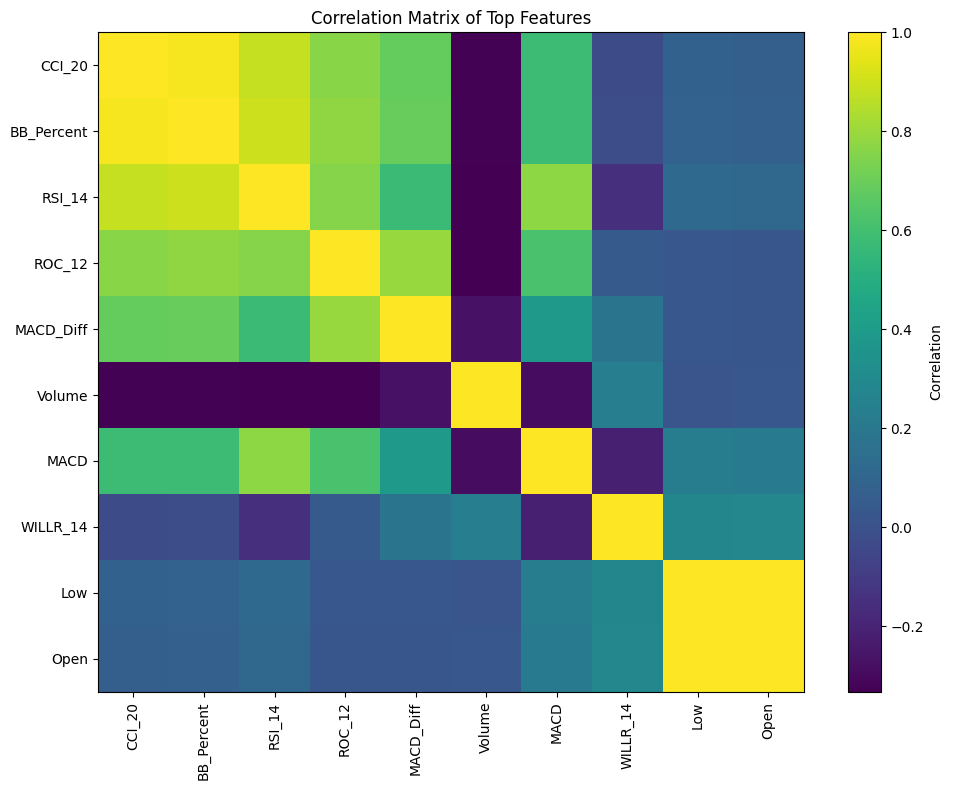

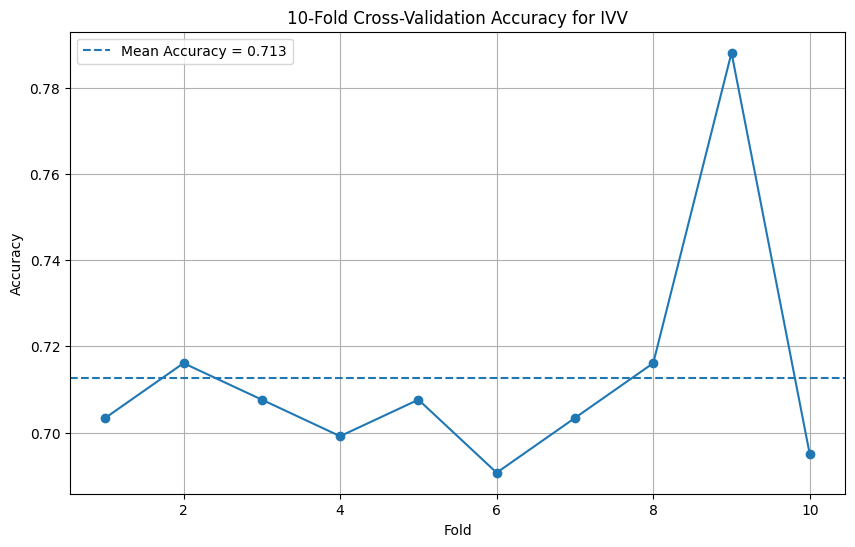

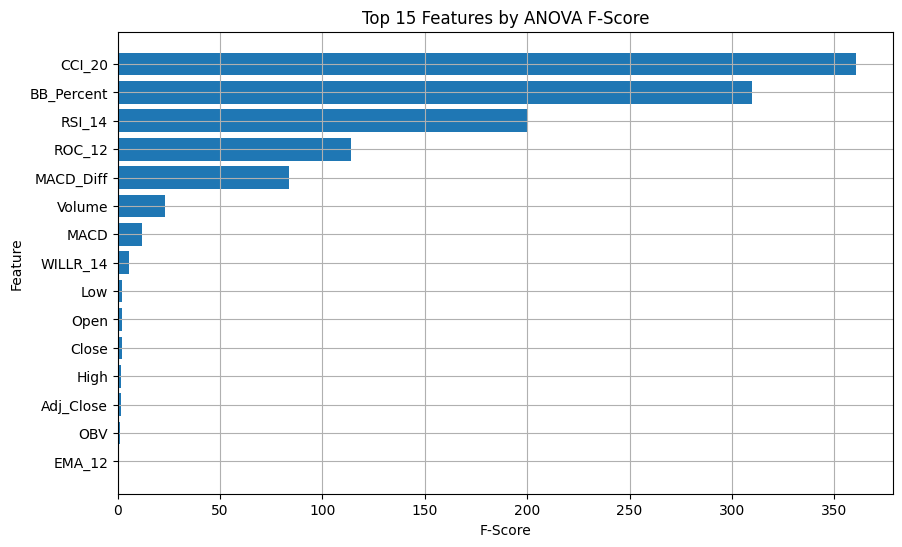

Checking saved figures:
Figure_1_IVV_Adjusted_Closing_Price.png FOUND
Figure_2_Correlation_Ranking.png FOUND
Figure_3_Correlation_Matrix.png FOUND
Figure_4_Cross_Validation.png FOUND
Figure_5_ANOVA_Feature_Importance.png FOUND
✓ Added: cleaned_oil_stock_data.csv
✓ Added: IVV_with_indicators.csv
✓ Added: IVV_descriptive_statistics.csv
✓ Added: IVV_correlation_ranking.csv
✓ Added: IVV_cross_validation_results.csv
✓ Added: IVV_anova_feature_scores.csv
✓ Added: Figure_1_IVV_Adjusted_Closing_Price.png
✓ Added: Figure_2_Correlation_Ranking.png
✓ Added: Figure_3_Correlation_Matrix.png
✓ Added: Figure_4_Cross_Validation.png
✓ Added: Figure_5_ANOVA_Feature_Importance.png

ZIP contents:
 - cleaned_oil_stock_data.csv
 - IVV_with_indicators.csv
 - IVV_descriptive_statistics.csv
 - IVV_correlation_ranking.csv
 - IVV_cross_validation_results.csv
 - IVV_anova_feature_scores.csv
 - Figure_1_IVV_Adjusted_Closing_Price.png
 - Figure_2_Correlation_Ranking.png
 - Figure_3_Correlation_Matrix.png
 - Figure_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Final ZIP downloaded with CSV files and PNG figures.


In [ ]:
# ============================================================
# MScFE 600 GWP1
# Save all plots as 300 dpi PNG files, then ZIP everything
# ============================================================

import os
import zipfile
import matplotlib.pyplot as plt
from google.colab import files

# ------------------------------------------------------------
# Figure 1: Adjusted closing price
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))
plt.plot(data.index, data["Adj_Close"])
plt.title("IVV Adjusted Closing Price")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.grid(True)
plt.savefig("Figure_1_IVV_Adjusted_Closing_Price.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Figure 2: Correlation ranking
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))
plt.barh(top_corr["Feature"], top_corr["Absolute_Correlation_with_Gamma"])
plt.title("Top 15 Features by Absolute Correlation with Gamma")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")
plt.grid(True)
plt.savefig("Figure_2_Correlation_Ranking.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Figure 3: Correlation matrix
# ------------------------------------------------------------

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(top_features)), top_features, rotation=90)
plt.yticks(range(len(top_features)), top_features)
plt.title("Correlation Matrix of Top Features")
plt.tight_layout()
plt.savefig("Figure_3_Correlation_Matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Figure 4: Cross-validation accuracy
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))
plt.plot(cv_results["Fold"], cv_results["Accuracy"], marker="o")
plt.axhline(
    scores.mean(),
    linestyle="--",
    label=f"Mean Accuracy = {scores.mean():.3f}"
)
plt.title("10-Fold Cross-Validation Accuracy for IVV")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("Figure_4_Cross_Validation.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Figure 5: ANOVA feature importance
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))
plt.barh(top_f_scores["Feature"], top_f_scores["F_Score"])
plt.title("Top 15 Features by ANOVA F-Score")
plt.xlabel("F-Score")
plt.ylabel("Feature")
plt.grid(True)
plt.savefig("Figure_5_ANOVA_Feature_Importance.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Confirm figures exist
# ------------------------------------------------------------

figure_files = [
    "Figure_1_IVV_Adjusted_Closing_Price.png",
    "Figure_2_Correlation_Ranking.png",
    "Figure_3_Correlation_Matrix.png",
    "Figure_4_Cross_Validation.png",
    "Figure_5_ANOVA_Feature_Importance.png"
]

print("Checking saved figures:")
for fig in figure_files:
    print(fig, "FOUND" if os.path.exists(fig) else "MISSING")

# ------------------------------------------------------------
# ZIP all CSV files and PNG figures
# ------------------------------------------------------------

submission_files = [
    "cleaned_oil_stock_data.csv",
    "IVV_with_indicators.csv",
    "IVV_descriptive_statistics.csv",
    "IVV_correlation_ranking.csv",
    "IVV_cross_validation_results.csv",
    "IVV_anova_feature_scores.csv",
] + figure_files

zip_name = "MScFE600_GWP1_Final_Submission_With_Figures.zip"

with zipfile.ZipFile(zip_name, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
    for file in submission_files:
        if os.path.exists(file):
            zipf.write(file, arcname=file)
            print(f"✓ Added: {file}")
        else:
            print(f"⚠ Missing: {file}")

print("\nZIP contents:")
with zipfile.ZipFile(zip_name, "r") as zipf:
    for name in zipf.namelist():
        print(" -", name)

files.download(zip_name)

print("\n✓ Final ZIP downloaded with CSV files and PNG figures.")